# Yapay Sinir Ağları — F26 Dönem Ödevi
## El Yazısı Rakam Görüntülerinin Makine Öğrenmesi ve Derin Öğrenme ile Sınıflandırılması

**Öğrenci:** Reyhan Onbaşı  
**Öğrenci No:** 202612696008  
**İlgi alanı bağlantısı:** Yapay zekâ, makine öğrenmesi, derin öğrenme, görüntü işleme ve bilgisayarlı görü  
**Veri seti:** Scikit-learn Digits — 1.797 adet 8×8 gri-seviye el yazısı rakam görüntüsü, 10 sınıf  
**Veri erişim bağlantısı:** https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_digits.html  
**Orijinal veri kaynağı:** https://archive.ics.uci.edu/dataset/80/optical+recognition+of+handwritten+digits

> **Bu notebook Google Colab ortamında eğitilmiş ve hücre çıktıları kaydedilmiştir.** Sonuçlar, bu notebook içinde kayıtlı gerçek eğitim/validation/test çıktılarından raporlanmıştır.

### Araştırma sorusu

Klasik makine öğrenmesi algoritmaları ile düzenlileştirilmiş çok katmanlı yapay sinir ağı (MLP) ve evrişimli sinir ağı (CNN), düşük çözünürlüklü el yazısı rakam görüntülerini ne kadar başarılı sınıflandırabilir? Dropout, L2 ve erken durdurma aşırı öğrenmeyi ne ölçüde sınırlar?

> **Metodolojik kural:** Hiperparametreler yalnızca training/CV ile ayarlanır. Model ailesi ve sinir ağı mimarisi validation kümesiyle seçilir. Test kümesi seçim kararlarında kullanılmaz; seçim bittikten sonra final değerlendirmede açılır.

In [1]:
import os, random, warnings, json
from pathlib import Path

os.environ["PYTHONHASHSEED"] = "42"
os.environ["TF_DETERMINISTIC_OPS"] = "1"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score, roc_auc_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
)

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers, regularizers

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)
try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")
FIG_DPI = 600
OUTPUT_DIR = Path("digits_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

print("TensorFlow:", tf.__version__)
print("Sabit seed:", SEED, "| Şekil çözünürlüğü:", FIG_DPI, "dpi")

TensorFlow: 2.20.0
Sabit seed: 42 | Şekil çözünürlüğü: 600 dpi


## 1. Veri Seti ve İlgi Alanıyla İlişkisi

Digits veri seti, `0–9` arasındaki el yazısı rakamların görüntülerini içerir. Her görüntü 8×8 pikselden oluşur ve piksel yoğunlukları 0–16 aralığındadır. Bu problem doğrudan **görüntü işleme, bilgisayarlı görü, örüntü tanıma, yapay zekâ ve derin öğrenme** alanlarıyla ilgilidir.

Veri seti scikit-learn içinde hazır bulunduğundan ayrıca dosya yüklemeye veya internet bağlantısına gerek yoktur. Kaynak: UCI Optical Recognition of Handwritten Digits veri tabanının scikit-learn test alt kümesi.

In [2]:
digits = load_digits()
X = digits.data.astype("float32")          # (1797, 64)
images = digits.images.astype("float32")  # (1797, 8, 8)
y = digits.target.astype("int64")         # 0-9
class_names = np.array([str(i) for i in digits.target_names])

assert X.shape == (1797, 64)
assert images.shape == (1797, 8, 8)
assert len(np.unique(y)) == 10
assert not np.isnan(X).any()

print("Örnek sayısı:", len(X))
print("Görüntü boyutu:", images.shape[1:])
print("Özellik sayısı:", X.shape[1])
print("Sınıflar:", class_names.tolist())
print("Piksel aralığı:", float(X.min()), "-", float(X.max()))

Örnek sayısı: 1797
Görüntü boyutu: (8, 8)
Özellik sayısı: 64
Sınıflar: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
Piksel aralığı: 0.0 - 16.0


## 2. Keşifsel Veri Analizi

In [3]:
# Tablo 1 — veri seti özeti
counts = pd.Series(y).value_counts().sort_index()
dataset_summary = pd.DataFrame({
    "Sınıf": counts.index,
    "Örnek_sayısı": counts.values,
    "Yüzde": (100 * counts.values / len(y)).round(2)
})
dataset_summary.to_csv(OUTPUT_DIR/"table_1_dataset_summary.csv", index=False)
display(dataset_summary)
print("Eksik değer:", int(np.isnan(X).sum()))
print("Sınıf büyüklüğü min/max farkı:", int(counts.max() - counts.min()))

,Sınıf,Örnek_sayısı,Yüzde
0,0,178,9.91
1,1,182,10.13
2,2,177,9.85
3,3,183,10.18
4,4,181,10.07
5,5,182,10.13
6,6,181,10.07
7,7,179,9.96
8,8,174,9.68
9,9,180,10.02


Eksik değer: 0
Sınıf büyüklüğü min/max farkı: 9


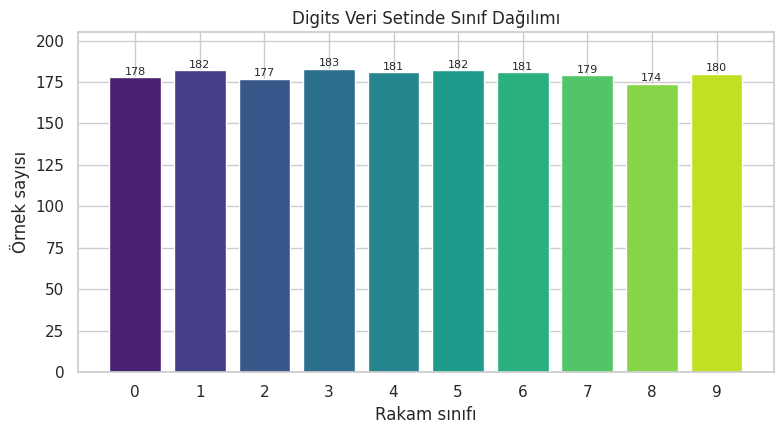

Yorum: Sınıflar dengelidir; en büyük ve en küçük sınıf arasındaki fark yalnızca 9 örnektir.


In [4]:
# Şekil 1 — sınıf dağılımı
fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(dataset_summary["Sınıf"].astype(str), dataset_summary["Örnek_sayısı"],
              color=sns.color_palette("viridis", 10))
for bar, value in zip(bars, dataset_summary["Örnek_sayısı"]):
    ax.text(bar.get_x()+bar.get_width()/2, value+1.5, str(value), ha="center", fontsize=8)
ax.set(title="Digits Veri Setinde Sınıf Dağılımı", xlabel="Rakam sınıfı", ylabel="Örnek sayısı")
ax.set_ylim(0, dataset_summary["Örnek_sayısı"].max()*1.12)
plt.tight_layout()
plt.savefig(OUTPUT_DIR/"figure_1_class_distribution.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()
print("Yorum: Sınıflar dengelidir; en büyük ve en küçük sınıf arasındaki fark yalnızca",
      int(counts.max()-counts.min()), "örnektir.")

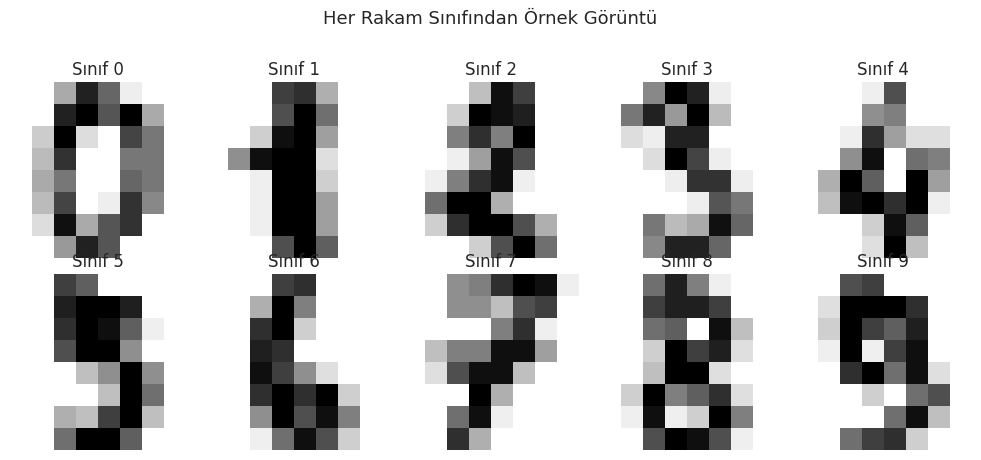

In [5]:
# Şekil 2 — her sınıftan bir örnek görüntü
fig, axes = plt.subplots(2, 5, figsize=(10, 4.5))
for digit, ax in enumerate(axes.ravel()):
    idx = np.flatnonzero(y == digit)[0]
    ax.imshow(images[idx], cmap="gray_r", interpolation="nearest")
    ax.set_title(f"Sınıf {digit}")
    ax.axis("off")
plt.suptitle("Her Rakam Sınıfından Örnek Görüntü", y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR/"figure_2_sample_images.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()

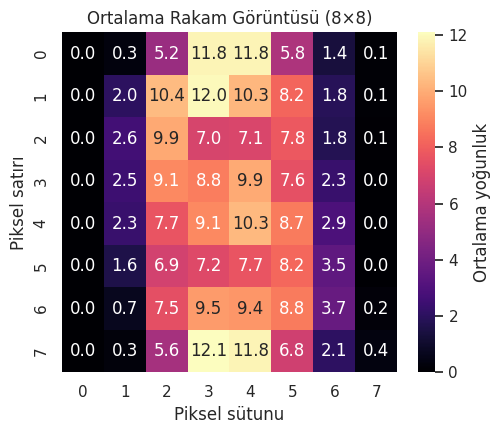

In [6]:
# Şekil 3 — tüm görüntülerin ortalama piksel yoğunluğu
fig, ax = plt.subplots(figsize=(5.2, 4.5))
sns.heatmap(images.mean(axis=0), cmap="magma", annot=True, fmt=".1f", cbar_kws={"label": "Ortalama yoğunluk"}, ax=ax)
ax.set_title("Ortalama Rakam Görüntüsü (8×8)")
ax.set_xlabel("Piksel sütunu"); ax.set_ylabel("Piksel satırı")
plt.tight_layout()
plt.savefig(OUTPUT_DIR/"figure_3_mean_pixel_heatmap.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()

## 3. Train / Validation / Test Ayrımı

- Training: %70 — öğrenme ve 5-fold CV hiperparametre araması
- Validation: %15 — algoritma ve sinir ağı mimarisi seçimi
- Test: %15 — bütün seçimlerden sonra bağımsız final değerlendirme

`stratify=y` ile her rakam sınıfının oranı üç alt kümede korunur. Bütün modeller aynı bölmeyi kullanır.

In [7]:
indices = np.arange(len(y))
idx_train, idx_temp = train_test_split(
    indices, test_size=0.30, stratify=y, random_state=SEED
)
idx_val, idx_test = train_test_split(
    idx_temp, test_size=0.50, stratify=y[idx_temp], random_state=SEED
)

X_train, X_val, X_test = X[idx_train], X[idx_val], X[idx_test]
y_train, y_val, y_test = y[idx_train], y[idx_val], y[idx_test]
img_train, img_val, img_test = images[idx_train], images[idx_val], images[idx_test]

split_rows = []
for name, labels in [("Train", y_train), ("Validation", y_val), ("Test", y_test)]:
    row = {"Küme": name, "Toplam": len(labels)}
    row.update({f"Sınıf_{d}": int(np.sum(labels == d)) for d in range(10)})
    split_rows.append(row)
split_table = pd.DataFrame(split_rows)
split_table.to_csv(OUTPUT_DIR/"table_2_data_split.csv", index=False)
display(split_table)

# Sinir ağları için 0-16 piksel değerlerini 0-1 aralığına getiriyoruz.
# Sabit fiziksel aralıkla bölme data leakage oluşturmaz.
X_train_nn, X_val_nn, X_test_nn = X_train/16.0, X_val/16.0, X_test/16.0
img_train_cnn = (img_train/16.0)[..., np.newaxis]
img_val_cnn = (img_val/16.0)[..., np.newaxis]
img_test_cnn = (img_test/16.0)[..., np.newaxis]

,Küme,Toplam,Sınıf_0,Sınıf_1,Sınıf_2,Sınıf_3,Sınıf_4,Sınıf_5,Sınıf_6,Sınıf_7,Sınıf_8,Sınıf_9
0,Train,1257,124,127,124,128,127,127,127,125,122,126
1,Validation,270,27,27,27,27,27,28,27,27,26,27
2,Test,270,27,28,26,28,27,27,27,27,26,27


## 4. Ortak Değerlendirme ve Model Seçimi

Çok sınıflı problemde birincil seçim metriği **Macro F1**'dir. Bu metrik her sınıfa eşit ağırlık verir. Eşitlik durumunda Macro ROC-AUC, ardından daha düşük model karmaşıklığı dikkate alınır. Aşırı öğrenme farkı `train accuracy − validation accuracy` olarak hesaplanır; test verisi overfitting kararı için kullanılmaz.

In [8]:
def multiclass_auc(y_true, probabilities):
    return roc_auc_score(y_true, probabilities, multi_class="ovr", average="macro")

def metric_row(name, y_tr, pred_tr, prob_tr, y_va, pred_va, prob_va,
               cv_best=np.nan, complexity=np.nan, family="Klasik ML"):
    return {
        "Model": name,
        "Aile": family,
        "CV_Best_Macro_F1": cv_best,
        "Train_Accuracy": accuracy_score(y_tr, pred_tr),
        "Validation_Accuracy": accuracy_score(y_va, pred_va),
        "Validation_Macro_F1": f1_score(y_va, pred_va, average="macro"),
        "Validation_Weighted_F1": f1_score(y_va, pred_va, average="weighted"),
        "Validation_Macro_Precision": precision_score(y_va, pred_va, average="macro", zero_division=0),
        "Validation_Macro_Recall": recall_score(y_va, pred_va, average="macro", zero_division=0),
        "Validation_Macro_ROC_AUC": multiclass_auc(y_va, prob_va),
        "Train_Val_Gap": accuracy_score(y_tr, pred_tr) - accuracy_score(y_va, pred_va),
        "Complexity": complexity,
    }

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
classic_specs = {
    "Logistic Regression": (
        Pipeline([("scaler", StandardScaler()),
                  ("clf", LogisticRegression(max_iter=5000, random_state=SEED))]),
        {"clf__C": [0.01, 0.1, 1, 10]}
    ),
    "KNN": (
        Pipeline([("scaler", StandardScaler()), ("clf", KNeighborsClassifier())]),
        {"clf__n_neighbors": [3, 5, 7, 9, 11], "clf__weights": ["uniform", "distance"], "clf__p": [1, 2]}
    ),
    "Random Forest": (
        RandomForestClassifier(random_state=SEED, n_jobs=-1),
        {"n_estimators": [300, 500], "max_depth": [12, None],
         "min_samples_leaf": [1, 2], "max_features": ["sqrt", 0.5]}
    ),
    "SVM (RBF)": (
        Pipeline([("scaler", StandardScaler()),
                  ("clf", SVC(kernel="rbf", probability=True, random_state=SEED))]),
        {"clf__C": [1, 3, 10], "clf__gamma": ["scale", 0.001, 0.01, 0.03]}
    ),
    "Gradient Boosting": (
        HistGradientBoostingClassifier(random_state=SEED),
        {"learning_rate": [0.05, 0.1], "max_iter": [100, 200],
         "max_leaf_nodes": [15, 31], "l2_regularization": [0.0, 0.1]}
    ),
}

## 5. Beş Klasik Makine Öğrenmesi Algoritması

In [9]:
classic_models, selection_rows, tuning_rows = {}, [], []

for name, (estimator, param_grid) in classic_specs.items():
    search = GridSearchCV(
        estimator, param_grid, scoring="f1_macro", cv=cv,
        n_jobs=-1, refit=True, return_train_score=False
    )
    search.fit(X_train, y_train)
    model = search.best_estimator_
    classic_models[name] = model

    pred_tr, pred_va = model.predict(X_train), model.predict(X_val)
    prob_tr, prob_va = model.predict_proba(X_train), model.predict_proba(X_val)
    selection_rows.append(metric_row(
        name, y_train, pred_tr, prob_tr, y_val, pred_va, prob_va,
        cv_best=search.best_score_, complexity=len(search.cv_results_["params"])
    ))
    tuning_rows.append({
        "Model": name,
        "En_iyi_parametreler": str(search.best_params_),
        "CV_Macro_F1": search.best_score_,
        "Denenen_kombinasyon": len(search.cv_results_["params"])
    })
    print(f"{name:22s} | CV Macro-F1={search.best_score_:.4f} | "
          f"Val Macro-F1={f1_score(y_val, pred_va, average='macro'):.4f}")

tuning_table = pd.DataFrame(tuning_rows)
tuning_table.to_csv(OUTPUT_DIR/"table_3_classic_tuning.csv", index=False)
display(tuning_table)

Logistic Regression    | CV Macro-F1=0.9642 | Val Macro-F1=0.9777
KNN                    | CV Macro-F1=0.9687 | Val Macro-F1=0.9625
Random Forest          | CV Macro-F1=0.9737 | Val Macro-F1=0.9661
SVM (RBF)              | CV Macro-F1=0.9800 | Val Macro-F1=0.9742
Gradient Boosting      | CV Macro-F1=0.9689 | Val Macro-F1=0.9512


,Model,En_iyi_parametreler,CV_Macro_F1,Denenen_kombinasyon
0,Logistic Regression,{'clf__C': 1},0.964227,4
1,KNN,"{'clf__n_neighbors': 5, 'clf__p': 2, 'clf__wei...",0.968657,20
2,Random Forest,"{'max_depth': 12, 'max_features': 'sqrt', 'min...",0.973651,16
3,SVM (RBF),"{'clf__C': 3, 'clf__gamma': 0.01}",0.979986,12
4,Gradient Boosting,"{'l2_regularization': 0.0, 'learning_rate': 0....",0.968867,16


## 6. Derin Öğrenme Deneyleri: MLP ve CNN

Üç yapılandırma denenir:

1. Daha küçük MLP — düşük kapasite ve kontrollü Dropout
2. Daha geniş MLP — daha yüksek temsil gücü ve daha güçlü düzenlileştirme
3. CNN — 8×8 görüntünün uzamsal komşuluk bilgisini kullanan evrişimli mimari

Tümünde L2, Dropout, `EarlyStopping(restore_best_weights=True)` ve `ReduceLROnPlateau` bulunur. 250 epoch yalnızca üst sınırdır; eğitim validation kaybına göre daha erken durur.

In [10]:
def build_mlp(hidden_units, dropout, l2_value, learning_rate):
    model = models.Sequential([layers.Input(shape=(64,))])
    for units in hidden_units:
        model.add(layers.Dense(units, activation="relu", kernel_initializer="he_normal",
                               kernel_regularizer=regularizers.l2(l2_value)))
        model.add(layers.Dropout(dropout))
    model.add(layers.Dense(10, activation="softmax"))
    model.compile(optimizer=optimizers.Adam(learning_rate=learning_rate),
                  loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

def build_cnn(dropout, l2_value, learning_rate):
    model = models.Sequential([
        layers.Input(shape=(8, 8, 1)),
        layers.Conv2D(32, 3, padding="same", activation="relu",
                      kernel_regularizer=regularizers.l2(l2_value)),
        layers.BatchNormalization(),
        layers.Conv2D(32, 3, padding="same", activation="relu",
                      kernel_regularizer=regularizers.l2(l2_value)),
        layers.MaxPooling2D(2),
        layers.Dropout(dropout),
        layers.Conv2D(64, 3, padding="same", activation="relu",
                      kernel_regularizer=regularizers.l2(l2_value)),
        layers.GlobalAveragePooling2D(),
        layers.Dense(64, activation="relu", kernel_regularizer=regularizers.l2(l2_value)),
        layers.Dropout(dropout),
        layers.Dense(10, activation="softmax")
    ])
    model.compile(optimizer=optimizers.Adam(learning_rate=learning_rate),
                  loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

neural_configs = [
    {"Config": "MLP-A Kompakt", "Type": "MLP", "hidden": (128, 64),
     "dropout": 0.25, "l2": 1e-4, "lr": 1e-3, "batch": 32},
    {"Config": "MLP-B Geniş", "Type": "MLP", "hidden": (256, 128, 64),
     "dropout": 0.35, "l2": 5e-4, "lr": 5e-4, "batch": 32},
    {"Config": "CNN-C Görüntü modeli", "Type": "CNN", "hidden": None,
     "dropout": 0.30, "l2": 1e-4, "lr": 1e-3, "batch": 32},
]

In [11]:
neural_rows, neural_models, neural_histories = [], {}, {}

for index, cfg in enumerate(neural_configs):
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(SEED + index)

    if cfg["Type"] == "CNN":
        model = build_cnn(cfg["dropout"], cfg["l2"], cfg["lr"])
        train_input, val_input = img_train_cnn, img_val_cnn
    else:
        model = build_mlp(cfg["hidden"], cfg["dropout"], cfg["l2"], cfg["lr"])
        train_input, val_input = X_train_nn, X_val_nn

    cb = [
        callbacks.EarlyStopping(monitor="val_loss", patience=18, min_delta=1e-4,
                                restore_best_weights=True, mode="min"),
        callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=7,
                                    min_lr=1e-6, mode="min")
    ]
    hist = model.fit(
        train_input, y_train, validation_data=(val_input, y_val),
        epochs=250, batch_size=cfg["batch"], callbacks=cb, verbose=0, shuffle=True
    )

    prob_tr = model.predict(train_input, verbose=0)
    prob_va = model.predict(val_input, verbose=0)
    pred_tr, pred_va = prob_tr.argmax(axis=1), prob_va.argmax(axis=1)
    best_epoch = int(np.argmin(hist.history["val_loss"]) + 1)

    row = {
        "Config": cfg["Config"], "Mimari": cfg["Type"],
        "Hidden_Units": str(cfg["hidden"]), "Dropout": cfg["dropout"],
        "L2": cfg["l2"], "Learning_Rate": cfg["lr"], "Batch": cfg["batch"],
        "Epochs_Run": len(hist.history["loss"]), "Best_Epoch": best_epoch,
        "Min_Val_Loss": float(np.min(hist.history["val_loss"])),
        "Val_Accuracy": accuracy_score(y_val, pred_va),
        "Val_Macro_F1": f1_score(y_val, pred_va, average="macro"),
        "Val_Macro_ROC_AUC": multiclass_auc(y_val, prob_va),
        "Param_Count": model.count_params()
    }
    neural_rows.append(row)
    neural_models[cfg["Config"]] = model
    neural_histories[cfg["Config"]] = hist.history
    print(f"{cfg['Config']:24s} | Run={row['Epochs_Run']:3d} | Best={best_epoch:3d} | "
          f"Val Macro-F1={row['Val_Macro_F1']:.4f}")

neural_table = pd.DataFrame(neural_rows)
neural_table.to_csv(OUTPUT_DIR/"table_4_neural_experiments.csv", index=False)
display(neural_table.round(4))

MLP-A Kompakt            | Run= 43 | Best= 25 | Val Macro-F1=0.9776
MLP-B Geniş              | Run=238 | Best=220 | Val Macro-F1=0.9813
CNN-C Görüntü modeli     | Run= 46 | Best= 28 | Val Macro-F1=0.9964


,Config,Mimari,Hidden_Units,Dropout,L2,Learning_Rate,Batch,Epochs_Run,Best_Epoch,Min_Val_Loss,Val_Accuracy,Val_Macro_F1,Val_Macro_ROC_AUC,Param_Count
0,MLP-A Kompakt,MLP,"(128, 64)",0.25,0.0001,0.0010,32,43,25,0.1403,0.9778,0.9776,0.9992,17226
1,MLP-B Geniş,MLP,"(256, 128, 64)",0.35,0.0005,0.0005,32,238,220,0.1976,0.9815,0.9813,0.9996,58442
2,CNN-C Görüntü modeli,CNN,None,0.30,0.0001,0.0010,32,46,28,0.0350,0.9963,0.9964,1.0000,33002


In [12]:
# Açık tie-break: Macro-F1 yüksek, AUC yüksek, val_loss düşük, parametre sayısı düşük.
neural_ranked = neural_table.sort_values(
    ["Val_Macro_F1", "Val_Macro_ROC_AUC", "Min_Val_Loss", "Param_Count"],
    ascending=[False, False, True, True], kind="mergesort"
).reset_index(drop=True)

best_neural_name = neural_ranked.loc[0, "Config"]
best_neural_type = neural_ranked.loc[0, "Mimari"]
best_neural = neural_models[best_neural_name]
best_history = neural_histories[best_neural_name]
best_epoch = int(neural_ranked.loc[0, "Best_Epoch"])

if best_neural_type == "CNN":
    train_input, val_input, test_input = img_train_cnn, img_val_cnn, img_test_cnn
else:
    train_input, val_input, test_input = X_train_nn, X_val_nn, X_test_nn

prob_tr_nn = best_neural.predict(train_input, verbose=0)
prob_va_nn = best_neural.predict(val_input, verbose=0)
pred_tr_nn, pred_va_nn = prob_tr_nn.argmax(axis=1), prob_va_nn.argmax(axis=1)

selection_rows.append(metric_row(
    f"{best_neural_type} ({best_neural_name})",
    y_train, pred_tr_nn, prob_tr_nn, y_val, pred_va_nn, prob_va_nn,
    cv_best=np.nan, complexity=best_neural.count_params(), family="Derin Öğrenme"
))

print("Seçilen sinir ağı:", best_neural_name)
print("Gerçek en iyi epoch:", best_epoch)

Seçilen sinir ağı: CNN-C Görüntü modeli
Gerçek en iyi epoch: 28


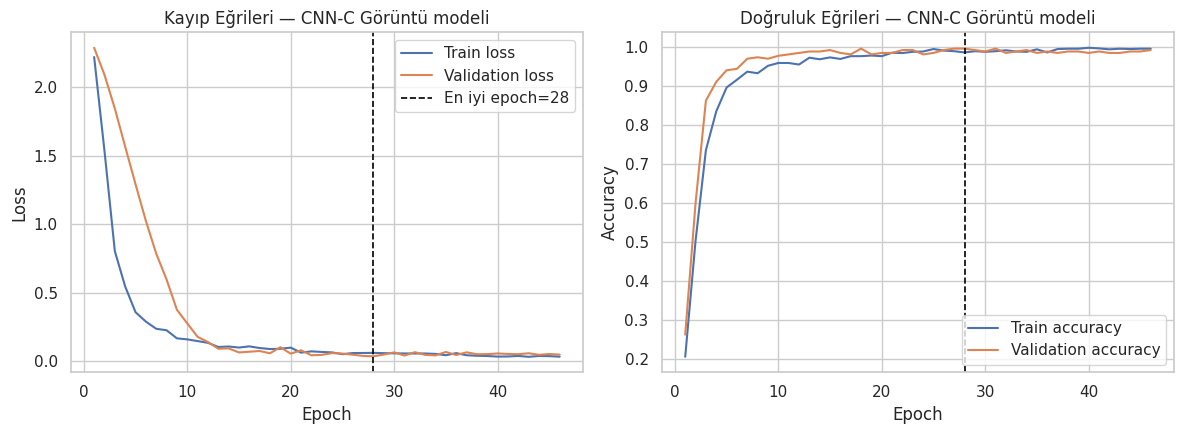

In [13]:
# Şekil 4 — seçilen sinir ağının eğitim eğrileri
epochs = np.arange(1, len(best_history["loss"]) + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(epochs, best_history["loss"], label="Train loss")
axes[0].plot(epochs, best_history["val_loss"], label="Validation loss")
axes[0].axvline(best_epoch, color="black", ls="--", lw=1.2, label=f"En iyi epoch={best_epoch}")
axes[0].set(title=f"Kayıp Eğrileri — {best_neural_name}", xlabel="Epoch", ylabel="Loss")
axes[0].legend()
axes[1].plot(epochs, best_history["accuracy"], label="Train accuracy")
axes[1].plot(epochs, best_history["val_accuracy"], label="Validation accuracy")
axes[1].axvline(best_epoch, color="black", ls="--", lw=1.2)
axes[1].set(title=f"Doğruluk Eğrileri — {best_neural_name}", xlabel="Epoch", ylabel="Accuracy")
axes[1].legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR/"figure_4_neural_learning_curves.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()

## 7. Validation ile Final Model Seçimi

,Model,Aile,CV_Best_Macro_F1,Train_Accuracy,Validation_Accuracy,Validation_Macro_F1,Validation_Weighted_F1,Validation_Macro_Precision,Validation_Macro_Recall,Validation_Macro_ROC_AUC,Train_Val_Gap,Complexity
0,CNN (CNN-C Görüntü modeli),Derin Öğrenme,NaN,1.0000,0.9963,0.9964,0.9963,0.9964,0.9964,1.0000,0.0037,33002
1,Logistic Regression,Klasik ML,0.9642,1.0000,0.9778,0.9777,0.9779,0.9780,0.9778,0.9990,0.0222,4
2,SVM (RBF),Klasik ML,0.9800,0.9984,0.9741,0.9742,0.9743,0.9754,0.9739,0.9989,0.0243,12
3,Random Forest,Klasik ML,0.9737,1.0000,0.9667,0.9661,0.9664,0.9669,0.9664,0.9989,0.0333,16
4,KNN,Klasik ML,0.9687,1.0000,0.9630,0.9625,0.9626,0.9636,0.9628,0.9917,0.0370,20
5,Gradient Boosting,Klasik ML,0.9689,1.0000,0.9519,0.9512,0.9514,0.9526,0.9514,0.9983,0.0481,16


Test açılmadan validation ile seçilen final model: CNN (CNN-C Görüntü modeli)


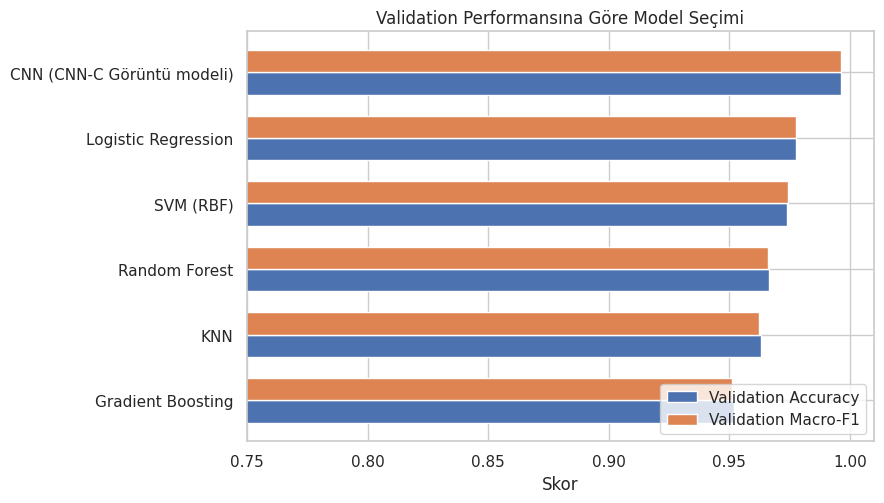

In [14]:
selection_table = pd.DataFrame(selection_rows).sort_values(
    ["Validation_Macro_F1", "Validation_Macro_ROC_AUC", "Complexity"],
    ascending=[False, False, True], kind="mergesort"
).reset_index(drop=True)
selection_table.to_csv(OUTPUT_DIR/"table_5_validation_model_selection.csv", index=False)
display(selection_table.round(4))

selected_model_name = selection_table.loc[0, "Model"]
print("Test açılmadan validation ile seçilen final model:", selected_model_name)

plot_df = selection_table.sort_values("Validation_Macro_F1")
fig, ax = plt.subplots(figsize=(9, 5.2))
ypos = np.arange(len(plot_df))
ax.barh(ypos-0.17, plot_df["Validation_Accuracy"], height=0.34, label="Validation Accuracy")
ax.barh(ypos+0.17, plot_df["Validation_Macro_F1"], height=0.34, label="Validation Macro-F1")
ax.set_yticks(ypos, plot_df["Model"])
ax.set_xlim(0.75, 1.01)
ax.set(title="Validation Performansına Göre Model Seçimi", xlabel="Skor")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig(OUTPUT_DIR/"figure_5_validation_comparison.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()

## 8. Bağımsız Test Değerlendirmesi

Test kümesi ancak bütün hiperparametre ve model seçimi kararları tamamlandıktan sonra açılır. Bütün modellerin test sonuçları şeffaf karşılaştırma amacıyla raporlanır; validation ile önceden verilen seçim kararı değiştirilmez.

In [15]:
test_rows, test_predictions, test_probabilities = [], {}, {}

for name, model in classic_models.items():
    pred = model.predict(X_test)
    prob = model.predict_proba(X_test)
    test_predictions[name], test_probabilities[name] = pred, prob
    test_rows.append({
        "Model": name,
        "Test_Accuracy": accuracy_score(y_test, pred),
        "Test_Macro_F1": f1_score(y_test, pred, average="macro"),
        "Test_Weighted_F1": f1_score(y_test, pred, average="weighted"),
        "Test_Macro_Precision": precision_score(y_test, pred, average="macro", zero_division=0),
        "Test_Macro_Recall": recall_score(y_test, pred, average="macro", zero_division=0),
        "Test_Macro_ROC_AUC": multiclass_auc(y_test, prob)
    })

neural_full_name = f"{best_neural_type} ({best_neural_name})"
prob_test_nn = best_neural.predict(test_input, verbose=0)
pred_test_nn = prob_test_nn.argmax(axis=1)
test_predictions[neural_full_name], test_probabilities[neural_full_name] = pred_test_nn, prob_test_nn
test_rows.append({
    "Model": neural_full_name,
    "Test_Accuracy": accuracy_score(y_test, pred_test_nn),
    "Test_Macro_F1": f1_score(y_test, pred_test_nn, average="macro"),
    "Test_Weighted_F1": f1_score(y_test, pred_test_nn, average="weighted"),
    "Test_Macro_Precision": precision_score(y_test, pred_test_nn, average="macro", zero_division=0),
    "Test_Macro_Recall": recall_score(y_test, pred_test_nn, average="macro", zero_division=0),
    "Test_Macro_ROC_AUC": multiclass_auc(y_test, prob_test_nn)
})

test_table = pd.DataFrame(test_rows)
final_table = selection_table.drop(columns=["Complexity"]).merge(test_table, on="Model", how="left")
final_table.insert(0, "Validation_Selected", final_table["Model"].eq(selected_model_name))
final_table.to_csv(OUTPUT_DIR/"table_6_final_performance.csv", index=False)
display(final_table.round(4))

selected_row = final_table.loc[final_table["Validation_Selected"]].iloc[0]
print("\nValidation ile seçilen model:", selected_model_name)
print(f"Final Test Accuracy={selected_row['Test_Accuracy']:.4f} | "
      f"Macro-F1={selected_row['Test_Macro_F1']:.4f} | "
      f"Macro ROC-AUC={selected_row['Test_Macro_ROC_AUC']:.4f}")
print("\nSınıflandırma raporu:")
print(classification_report(y_test, test_predictions[selected_model_name],
                            target_names=class_names, digits=4))

,Validation_Selected,Model,Aile,CV_Best_Macro_F1,Train_Accuracy,Validation_Accuracy,Validation_Macro_F1,Validation_Weighted_F1,Validation_Macro_Precision,Validation_Macro_Recall,Validation_Macro_ROC_AUC,Train_Val_Gap,Test_Accuracy,Test_Macro_F1,Test_Weighted_F1,Test_Macro_Precision,Test_Macro_Recall,Test_Macro_ROC_AUC
0,True,CNN (CNN-C Görüntü modeli),Derin Öğrenme,NaN,1.0000,0.9963,0.9964,0.9963,0.9964,0.9964,1.0000,0.0037,0.9852,0.9849,0.9851,0.9858,0.9848,1.0000
1,False,Logistic Regression,Klasik ML,0.9642,1.0000,0.9778,0.9777,0.9779,0.9780,0.9778,0.9990,0.0222,0.9852,0.9852,0.9852,0.9854,0.9850,0.9993
2,False,SVM (RBF),Klasik ML,0.9800,0.9984,0.9741,0.9742,0.9743,0.9754,0.9739,0.9989,0.0243,0.9889,0.9888,0.9889,0.9898,0.9886,0.9999
3,False,Random Forest,Klasik ML,0.9737,1.0000,0.9667,0.9661,0.9664,0.9669,0.9664,0.9989,0.0333,0.9741,0.9738,0.9739,0.9753,0.9736,0.9993
4,False,KNN,Klasik ML,0.9687,1.0000,0.9630,0.9625,0.9626,0.9636,0.9628,0.9917,0.0370,0.9815,0.9815,0.9815,0.9823,0.9813,0.9957
5,False,Gradient Boosting,Klasik ML,0.9689,1.0000,0.9519,0.9512,0.9514,0.9526,0.9514,0.9983,0.0481,0.9630,0.9627,0.9629,0.9634,0.9625,0.9980



Validation ile seçilen model: CNN (CNN-C Görüntü modeli)
Final Test Accuracy=0.9852 | Macro-F1=0.9849 | Macro ROC-AUC=1.0000

Sınıflandırma raporu:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000        27
           1     1.0000    1.0000    1.0000        28
           2     1.0000    0.9615    0.9804        26
           3     0.9655    1.0000    0.9825        28
           4     1.0000    1.0000    1.0000        27
           5     0.9643    1.0000    0.9818        27
           6     1.0000    0.9630    0.9811        27
           7     0.9643    1.0000    0.9818        27
           8     1.0000    0.9231    0.9600        26
           9     0.9643    1.0000    0.9818        27

    accuracy                         0.9852       270
   macro avg     0.9858    0.9848    0.9849       270
weighted avg     0.9857    0.9852    0.9851       270



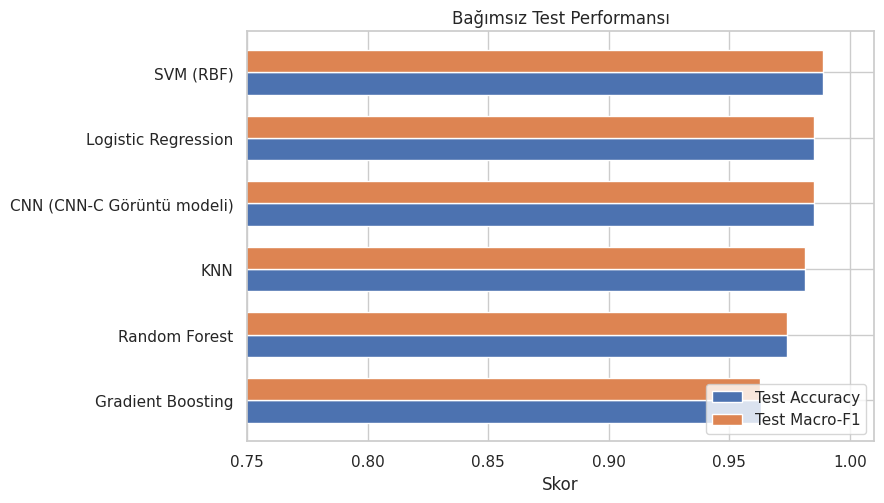

In [16]:
# Şekil 6 — test performansı
plot_df = test_table.sort_values("Test_Macro_F1")
fig, ax = plt.subplots(figsize=(9, 5.2))
ypos = np.arange(len(plot_df))
ax.barh(ypos-0.17, plot_df["Test_Accuracy"], height=0.34, label="Test Accuracy")
ax.barh(ypos+0.17, plot_df["Test_Macro_F1"], height=0.34, label="Test Macro-F1")
ax.set_yticks(ypos, plot_df["Model"])
ax.set_xlim(0.75, 1.01)
ax.set(title="Bağımsız Test Performansı", xlabel="Skor")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig(OUTPUT_DIR/"figure_6_test_comparison.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()

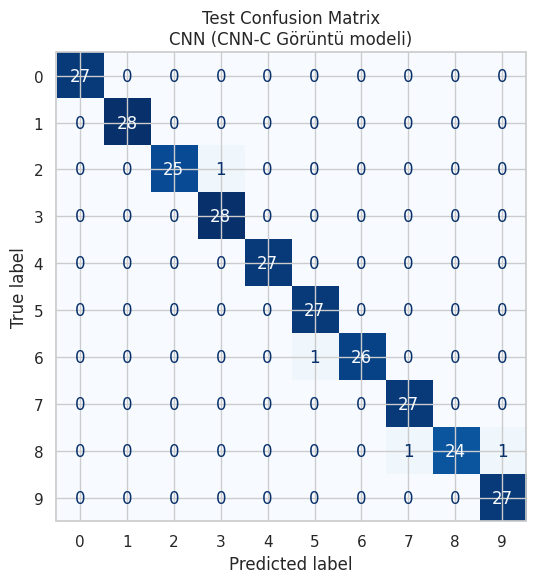

In [17]:
# Şekil 7 — validation ile seçilen modelin confusion matrix'i
fig, ax = plt.subplots(figsize=(7, 6))
cm = confusion_matrix(y_test, test_predictions[selected_model_name])
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title(f"Test Confusion Matrix\n{selected_model_name}")
plt.tight_layout()
plt.savefig(OUTPUT_DIR/"figure_7_confusion_matrix.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()

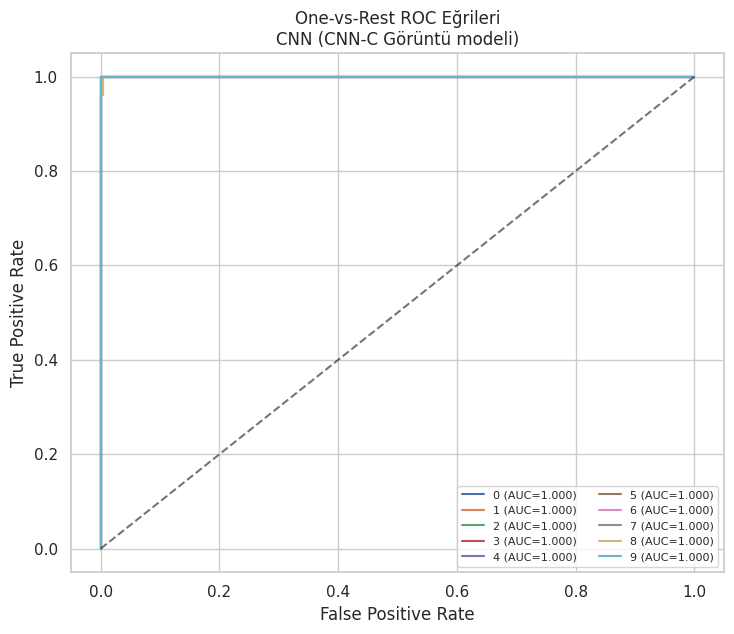

In [18]:
# Şekil 8 — seçilen model için sınıf-bazlı One-vs-Rest ROC eğrileri
selected_prob = test_probabilities[selected_model_name]
y_test_bin = label_binarize(y_test, classes=np.arange(10))
fig, ax = plt.subplots(figsize=(7.5, 6.5))
for digit in range(10):
    fpr, tpr, _ = roc_curve(y_test_bin[:, digit], selected_prob[:, digit])
    ax.plot(fpr, tpr, lw=1.5, label=f"{digit} (AUC={auc(fpr, tpr):.3f})")
ax.plot([0, 1], [0, 1], "k--", alpha=.6)
ax.set(title=f"One-vs-Rest ROC Eğrileri\n{selected_model_name}",
       xlabel="False Positive Rate", ylabel="True Positive Rate")
ax.legend(ncol=2, fontsize=8, loc="lower right")
plt.tight_layout()
plt.savefig(OUTPUT_DIR/"figure_8_multiclass_roc.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()

## 9. Overfitting / Genelleme Analizi

In [19]:
overfit_table = selection_table[[
    "Model", "Aile", "Train_Accuracy", "Validation_Accuracy",
    "Train_Val_Gap", "Validation_Macro_F1", "Validation_Macro_ROC_AUC"
]].copy().sort_values("Train_Val_Gap", ascending=False)
overfit_table["Yorum"] = np.select(
    [overfit_table["Train_Val_Gap"] > 0.05, overfit_table["Train_Val_Gap"] > 0.02],
    ["Belirgin overfitting riski", "Hafif overfitting işareti"],
    default="Genelleme farkı düşük"
)
overfit_table.to_csv(OUTPUT_DIR/"table_7_overfitting_analysis.csv", index=False)
display(overfit_table.round(4))

,Model,Aile,Train_Accuracy,Validation_Accuracy,Train_Val_Gap,Validation_Macro_F1,Validation_Macro_ROC_AUC,Yorum
5,Gradient Boosting,Klasik ML,1.0000,0.9519,0.0481,0.9512,0.9983,Hafif overfitting işareti
4,KNN,Klasik ML,1.0000,0.9630,0.0370,0.9625,0.9917,Hafif overfitting işareti
3,Random Forest,Klasik ML,1.0000,0.9667,0.0333,0.9661,0.9989,Hafif overfitting işareti
2,SVM (RBF),Klasik ML,0.9984,0.9741,0.0243,0.9742,0.9989,Hafif overfitting işareti
1,Logistic Regression,Klasik ML,1.0000,0.9778,0.0222,0.9777,0.9990,Hafif overfitting işareti
0,CNN (CNN-C Görüntü modeli),Derin Öğrenme,1.0000,0.9963,0.0037,0.9964,1.0000,Genelleme farkı düşük


## 10. Modelleri ve Çalıştırma Özetini Kaydetme

In [20]:
for name, model in classic_models.items():
    safe = name.lower().replace(" ", "_").replace("(", "").replace(")", "")
    joblib.dump(model, OUTPUT_DIR/f"model_{safe}.joblib")
best_neural.save(OUTPUT_DIR/"model_best_neural.keras")

run_summary = {
    "student": "Reyhan Onbaşı",
    "seed": SEED,
    "dataset": "scikit-learn Digits",
    "dataset_size": int(len(y)),
    "selected_model_by_validation": selected_model_name,
    "selected_neural_model": best_neural_name,
    "selected_neural_best_epoch": best_epoch,
    "test_was_not_used_for_selection": True,
    "primary_metric": "Macro F1",
    "dataset_url": "https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_digits.html",
    "original_dataset_url": "https://archive.ics.uci.edu/dataset/80/optical+recognition+of+handwritten+digits"
}
with open(OUTPUT_DIR/"run_summary.json", "w", encoding="utf-8") as f:
    json.dump(run_summary, f, ensure_ascii=False, indent=2)

print("Kaydedilen çıktı sayısı:", len(list(OUTPUT_DIR.iterdir())))
for path in sorted(OUTPUT_DIR.iterdir()):
    print("-", path.name)

Kaydedilen çıktı sayısı: 22
- figure_1_class_distribution.png
- figure_2_sample_images.png
- figure_3_mean_pixel_heatmap.png
- figure_4_neural_learning_curves.png
- figure_5_validation_comparison.png
- figure_6_test_comparison.png
- figure_7_confusion_matrix.png
- figure_8_multiclass_roc.png
- model_best_neural.keras
- model_gradient_boosting.joblib
- model_knn.joblib
- model_logistic_regression.joblib
- model_random_forest.joblib
- model_svm_rbf.joblib
- run_summary.json
- table_1_dataset_summary.csv
- table_2_data_split.csv
- table_3_classic_tuning.csv
- table_4_neural_experiments.csv
- table_5_validation_model_selection.csv
- table_6_final_performance.csv
- table_7_overfitting_analysis.csv


## 11. Akademik Dürüstlük ve Yapay Zekâ Kullanım Beyanı

Kodun yapılandırılması, açıklamaların geliştirilmesi ve hata kontrolünde üretken yapay zekâ desteği alınmıştır. Veri analizi, eğitim ve metrik hesaplamaları öğrenci tarafından Google Colab üzerinde notebook hücreleri çalıştırılarak üretilecektir. Raporlanan hiçbir sonuç önceden uydurulmayacak; raporlar yalnızca tamamlanmış notebook çıktıları temel alınarak hazırlanacaktır.

## 12. Eğitim Çıktılarını İndirme

Bu hücreyi yalnızca bütün hücreler başarıyla tamamlandıktan sonra çalıştırın:

1. Aşağıdaki hücre `Reyhan_Onbasi_Digits_Egitim_Ciktilari.zip` dosyasını indirir.
2. Colab menüsünden **Dosya → İndir → .ipynb dosyasını indir** seçeneğiyle çıktılı notebooku indirin.
3. Çıktılı notebooku ve ZIP dosyasını ChatGPT'ye yükleyin.
4. Rapor 1 ve akademik Rapor 2 gerçek çıktılara göre hazırlanacaktır.

In [21]:
from shutil import make_archive

archive_path = make_archive(
    "Reyhan_Onbasi_Digits_Egitim_Ciktilari",
    "zip",
    root_dir=OUTPUT_DIR
)
print("Hazır:", archive_path)

try:
    from google.colab import files
    files.download(archive_path)
except ImportError:
    print("Colab dışında çalışıyorsunuz; ZIP çalışma klasörüne kaydedildi.")

Hazır: /content/Reyhan_Onbasi_Digits_Egitim_Ciktilari.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>